# Time of Emergence — Three Framings
## GMSAT  |  G6-1.5K-HiLLA vs SSP2-4.5  |  MIROC-ES2H

Three detection methods applied to the same model (MIROC-ES2H, 10 members):

| Panel | Method | Information assumed known |
|---|---|---|
| 1 | **Signal-to-noise** — ensemble mean difference exceeds 1.645 σ of SSP2-4.5 internal variability | Both 10-member ensembles; noise estimated from SSP2-4.5 member spread (2025–2044) |
| 2 | **SSP2-4.5 counterfactual** — cumulative one-sided t-test (all years 2035–Y) | Both 10-member ensembles, tested member-by-member |
| 3 | **Obs-only** — OLS trend + AR(1) prediction interval on single realisation | SSP2-4.5 r01 (2020–2034) as pseudo-obs; HiLLA r01 as the new intervention, repeated over all members |

All timeseries are anomalies relative to the 2020–2039 ensemble mean of SSP2-4.5.

**Noise definition (Method 1):** standard deviation of individual SSP2-4.5 member annual values
around the SSP2-4.5 ensemble mean, pooled across all 10 members over the 20 years centred on
2035 (i.e. 2025–2044). This is a single fixed scalar used as a constant threshold.

In [1]:
import sys
import fsspec
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

matplotlib.rcParams.update({'font.size': 12})
sys.path.append('../shared/Code_examples/G6-1.5K_example/')
from Utils import weighted_annual_resample

SAI_START  = 2035
ANOM_REF   = (2020, 2039)   # SSP245 ensemble mean reference for anomalies
NOISE_WIN  = (2025, 2044)   # 20 years centred on 2035 for S:N noise estimate
PLOT_START = 2020
PLOT_END   = 2084
K_CONSEC   = 5              # consecutive years for obs-only ToE
CI_LEVEL   = 0.95
ALPHA      = 0.05
MIN_N      = 2              # minimum years for cumulative t-test
SN_K       = 1.645          # signal-to-noise threshold (one-sided 95th percentile)

In [2]:
# ── MIROC-ES2H ────────────────────────────────────────────────────────────────
_MIROC = 's3://reflective-persistent-prod-large/MIROC-ES2H/G6-1.5K-HiLLA/Amon'
N_MEM  = 10
miroc_HiLLA_files  = [f'{_MIROC}/tas_G6-1.5K-HiLLA_r{i:02d}.nc' for i in range(1, N_MEM + 1)]
miroc_ssp245_files = [f'{_MIROC}/tas_baseline_r{i:02d}.nc'       for i in range(1, N_MEM + 1)]
print(f'Defined {N_MEM} HiLLA and {N_MEM} SSP245 file paths.')

Defined 10 HiLLA and 10 SSP245 file paths.


In [3]:
def open_nc(path):
    with fsspec.open(path, mode='rb') as f:
        return xr.open_dataset(f, engine='h5netcdf', chunks={}).load()


def global_annual_mean(ds, var='tas', lat_name='lat'):
    """Area-weighted global annual mean; returns DataArray indexed by integer year."""
    da = ds[var]
    if float(da[lat_name][0]) > float(da[lat_name][-1]):
        da = da.sortby(lat_name)
    weights = np.cos(np.deg2rad(da[lat_name]))
    weights /= weights.sum()
    gmean = (da * weights).sum(lat_name).mean('lon')
    annual = weighted_annual_resample(gmean.to_dataset(name=var), var=var)[var]
    return annual.assign_coords(time=annual.time.dt.year.values)


print('Loading MIROC-ES2H...')
miroc_HiLLA_ds  = [open_nc(f) for f in miroc_HiLLA_files]
miroc_ssp245_ds = [open_nc(f) for f in miroc_ssp245_files]
print(f'  HiLLA:  {N_MEM} members, '
      f'{int(miroc_HiLLA_ds[0].time.dt.year.min())}–{int(miroc_HiLLA_ds[0].time.dt.year.max())}')
print(f'  SSP245: {N_MEM} members, '
      f'{int(miroc_ssp245_ds[0].time.dt.year.min())}–{int(miroc_ssp245_ds[0].time.dt.year.max())}')

Loading MIROC-ES2H...
  HiLLA:  10 members, 2035–2084
  SSP245: 10 members, 2020–2084


In [4]:
print('Computing global annual means...')
miroc_HiLLA_gmsat  = [global_annual_mean(ds) for ds in miroc_HiLLA_ds]
miroc_ssp245_gmsat = [global_annual_mean(ds) for ds in miroc_ssp245_ds]

# Anomaly reference: 2020–2039 ensemble mean of SSP245
ref = float(np.mean([
    float(ts.sel(time=slice(*ANOM_REF)).mean())
    for ts in miroc_ssp245_gmsat
]))
print(f'Anomaly reference (SSP245 ens mean {ANOM_REF[0]}–{ANOM_REF[1]}): {ref:.4f} K')

miroc_HiLLA_anom  = [ts - ref for ts in miroc_HiLLA_gmsat]
miroc_ssp245_anom = [ts - ref for ts in miroc_ssp245_gmsat]

# Convenience: stack to (n_members, n_years) arrays for ensemble plots
def stack_ens(ts_list, yr_start=PLOT_START, yr_end=PLOT_END):
    common = sorted(set.intersection(*[set(ts.time.values.tolist()) for ts in ts_list]))
    common = [y for y in common if yr_start <= y <= yr_end]
    return (np.stack([ts.sel(time=common).values for ts in ts_list]),
            np.array(common, dtype=int))

hilla_arr, hilla_yrs = stack_ens(miroc_HiLLA_anom)
ssp_arr,   ssp_yrs   = stack_ens(miroc_ssp245_anom)
print(f'Ensemble arrays: HiLLA {hilla_arr.shape}, SSP245 {ssp_arr.shape}')

Computing global annual means...
Anomaly reference (SSP245 ens mean 2020–2039): 288.7001 K
Ensemble arrays: HiLLA (10, 43), SSP245 (10, 65)


## Method 1 — Signal-to-noise diagnostic

**Signal:** difference in ensemble means — SSP2-4.5 minus G6-1.5K-HiLLA — at each year.

**Noise (σ):** standard deviation of individual SSP2-4.5 member annual values around the SSP2-4.5
ensemble mean, pooled across all 10 members over 2025–2044 (fixed scalar).

**ToE:** first year for which Signal > 1.645 σ  (i.e. the forced cooling exceeds the one-sided 95th-percentile noise threshold).

In [5]:
def signal_to_noise_toe(hilla_list, ssp245_list,
                        noise_win=NOISE_WIN, k=SN_K,
                        plot_start=PLOT_START, plot_end=PLOT_END):
    """
    Signal  = SSP245_ens_mean(Y) - HiLLA_ens_mean(Y)   [cooling is positive]
    Noise σ = std of SSP245 member residuals around SSP245 ens mean,
              pooled over all members and years in noise_win.
    ToE     = first year Signal > k * σ.
    """
    # ── noise estimate ────────────────────────────────────────────────────────
    noise_years = np.arange(noise_win[0], noise_win[1] + 1)
    ssp_noise_vals = np.stack([
        ts.sel(time=noise_years).values for ts in ssp245_list
    ])  # (n_members, n_noise_years)
    ssp_noise_mean = ssp_noise_vals.mean(axis=0)  # ensemble mean per year
    residuals = ssp_noise_vals - ssp_noise_mean    # member deviations
    sigma = float(residuals.std(ddof=1))           # pooled std (scalar)
    threshold = k * sigma
    print(f'Noise σ (SSP245 internal variability, {noise_win[0]}–{noise_win[1]}): {sigma:.4f} K')
    print(f'Threshold ({k} σ): {threshold:.4f} K')

    # ── signal timeseries ─────────────────────────────────────────────────────
    # Intersect years available in every member of both ensembles
    all_yrs = np.arange(SAI_START, plot_end + 1)
    common_yrs = all_yrs.copy()
    for ts in hilla_list + ssp245_list:
        common_yrs = np.intersect1d(common_yrs, ts.time.values.astype(int))

    hilla_mean = np.stack([ts.sel(time=common_yrs).values for ts in hilla_list]).mean(axis=0)
    ssp_mean   = np.stack([ts.sel(time=common_yrs).values for ts in ssp245_list]).mean(axis=0)
    signal     = ssp_mean - hilla_mean   # positive = cooling

    # ToE: first year signal exceeds threshold
    exceed = np.where(signal > threshold)[0]
    toe = int(common_yrs[exceed[0]]) if len(exceed) else None

    return sigma, threshold, common_yrs, signal, toe


sn_sigma, sn_threshold, sn_years, sn_signal, sn_toe = signal_to_noise_toe(
    miroc_HiLLA_anom, miroc_ssp245_anom
)
print(f'Method 1 (signal-to-noise)  ToE: {sn_toe}')


Noise σ (SSP245 internal variability, 2025–2044): 0.1709 K
Threshold (1.645 σ): 0.2811 K
Method 1 (signal-to-noise)  ToE: 2039


## Method 2 — Cumulative t-test (SSP2-4.5 counterfactual)
For year Y, collect all annual GMSAT values from 2035 to Y in one HiLLA member and its paired SSP2-4.5 member.
One-sided Welch's t-test (HiLLA < SSP245), p < 0.05.  
Member ToE = first significant year.  Median ToE = median across the 10 individual member ToEs.

In [6]:
def cumulative_ttest_toe(hilla_ts, ssp245_ts,
                         start_year=SAI_START, alpha=ALPHA, min_n=MIN_N):
    h_yrs = hilla_ts.time.values.astype(int);  h_vals = hilla_ts.values
    s_yrs = ssp245_ts.time.values.astype(int); s_vals = ssp245_ts.values
    h_yrs, h_vals = h_yrs[h_yrs >= start_year], h_vals[h_yrs >= start_year]
    s_yrs, s_vals = s_yrs[s_yrs >= start_year], s_vals[s_yrs >= start_year]
    end_year = int(min(h_yrs.max(), s_yrs.max()))
    p_vals = {}; toe = None
    for Y in range(start_year, end_year + 1):
        h_win = h_vals[h_yrs <= Y]
        s_win = s_vals[s_yrs <= Y]
        if min(len(h_win), len(s_win)) < min_n:
            p_vals[Y] = np.nan; continue
        _, p = stats.ttest_ind(h_win, s_win, equal_var=False, alternative='less')
        p_vals[Y] = p
        if toe is None and p < alpha:
            toe = Y
    return toe, p_vals


cm_mem_toes = []; cm_pvals_all = []
for h, s in zip(miroc_HiLLA_anom, miroc_ssp245_anom):
    toe, pvs = cumulative_ttest_toe(h, s)
    cm_mem_toes.append(toe); cm_pvals_all.append(pvs)

# 66th percentile ToE (7/10 members) — central case for main figure
_valid = [t for t in cm_mem_toes if t is not None]
cm_p66_toe = int(np.percentile(_valid, 66))

print(f'Method 2 (cumulative t-test)  member ToEs: {cm_mem_toes}')
print(f'Method 2 (cumulative t-test)  66th pct ToE: {cm_p66_toe}')


Method 2 (cumulative t-test)  member ToEs: [2041, 2039, 2037, 2042, 2037, 2039, 2037, 2037, 2037, 2040]
Method 2 (cumulative t-test)  66th pct ToE: 2039


## Method 3 — Obs-only: OLS trend + AR(1) prediction interval
Train an OLS linear trend on each MIROC-ES2H SSP2-4.5 member (2020–2034) as pseudo-observations.
Fit AR(1) to residuals and extrapolate a 95% prediction interval from 2035 onward.
ToE = first year GMSAT_HiLLA falls **below** the lower PI bound for K=5 consecutive years.
Quoted as the **median ToE across all 10 members**.

In [7]:
PRED_YEARS = np.arange(SAI_START, PLOT_END + 1)


def ar1_forecast(obs_ts, pred_years, ci=CI_LEVEL):
    """OLS linear trend + AR(1) residuals h-step forecast.

    Returns (mu, lower_ci, upper_ci) over pred_years.
    """
    x_fit = obs_ts.time.values.astype(float)
    y_fit = obs_ts.values.astype(float)
    slope, intercept, *_ = stats.linregress(x_fit, y_fit)
    resid  = y_fit - (slope * x_fit + intercept)
    phi    = np.dot(resid[1:], resid[:-1]) / np.dot(resid[:-1], resid[:-1])
    innov  = resid[1:] - phi * resid[:-1]
    sigma  = np.sqrt(np.sum(innov**2) / (len(innov) - 1))
    eps_last = resid[-1]
    h   = pred_years.astype(float) - x_fit[-1]
    mu  = slope * pred_years + intercept + phi**h * eps_last
    z       = stats.norm.ppf((1 + ci) / 2)
    pi_half = z * sigma * np.sqrt((1 - phi**(2*h)) / max(1 - phi**2, 1e-8))
    return mu, mu - pi_half, mu + pi_half


def ar1_toe_lower(hilla_ts, pred_years, lower_pi,
                  start_year=SAI_START, K=K_CONSEC):
    """First year HiLLA is below lower PI for K consecutive years."""
    h_yrs  = hilla_ts.time.values
    common = np.intersect1d(h_yrs[h_yrs >= start_year], pred_years)
    if len(common) < K:
        return None
    h_vals = hilla_ts.sel(time=common).values
    lo     = lower_pi[np.searchsorted(pred_years, common)]
    below  = h_vals < lo
    for i in range(len(below) - K + 1):
        if below[i: i + K].all():
            return int(common[i])
    return None


print(f'Method 3 — AR(1) per member (training 2020–{SAI_START - 1}):')
obs_toes_all    = []
ar1_results_all = []   # (mu, lo, hi) per member

for i in range(N_MEM):
    obs_i             = miroc_ssp245_anom[i].sel(time=slice(2020, SAI_START - 1))
    mu_i, lo_i, hi_i = ar1_forecast(obs_i, PRED_YEARS)
    toe_i             = ar1_toe_lower(miroc_HiLLA_anom[i], PRED_YEARS, lo_i)
    obs_toes_all.append(toe_i)
    ar1_results_all.append((mu_i, lo_i, hi_i))
    print(f'  r{i+1:02d}: ToE = {toe_i}')

obs_median_toe = int(np.median([t for t in obs_toes_all if t is not None]))
print(f'Method 3 member ToEs : {obs_toes_all}')
print(f'Method 3 median ToE  : {obs_median_toe}')

Method 3 — AR(1) per member (training 2020–2034):
  r01: ToE = 2039
  r02: ToE = 2037
  r03: ToE = 2035
  r04: ToE = 2059
  r05: ToE = 2037
  r06: ToE = 2043
  r07: ToE = 2037
  r08: ToE = 2040
  r09: ToE = 2039
  r10: ToE = 2042
Method 3 member ToEs : [2039, 2037, 2035, 2059, 2037, 2043, 2037, 2040, 2039, 2042]
Method 3 median ToE  : 2039


In [8]:
from itertools import combinations

# ── Parameter settings ────────────────────────────────────────────────────────
N_BOOT_RANGE = list(range(3, 10))   # 3..9  (n=10 is exact, no resampling)
ALL_IDX      = list(range(N_MEM))

M1_PARAMS = [
    {'k': 1.0,   'label': '1 σ'},
    {'k': 1.645, 'label': '1.645 σ'},
    {'k': 2.0,   'label': '2 σ'},
]
M2_PARAMS = [
    {'alpha': 0.01, 'pct': 99, 'label': 'p=0.01, 99th pct'},
    {'alpha': 0.05, 'pct': 66, 'label': 'p=0.05, 66th pct'},
    {'alpha': 0.10, 'pct': 50, 'label': 'p=0.10, 50th pct'},
]
M3_PARAMS = [
    {'ci': 0.90, 'K': 3,  'label': '90% PI, K=3'},
    {'ci': 0.95, 'K': 5,  'label': '95% PI, K=5'},
    {'ci': 0.99, 'K': 10, 'label': '99% PI, K=10'},
]

# ── Method 1 helper (requires recomputation per subset) ───────────────────────
def m1_toe_from_idx(idx, k, hilla_list=miroc_HiLLA_anom, ssp245_list=miroc_ssp245_anom,
                    noise_win=NOISE_WIN, plot_end=2065):
    noise_years = np.arange(noise_win[0], noise_win[1] + 1)
    ssp_noise = np.stack([ssp245_list[i].sel(time=noise_years).values for i in idx])
    sigma = float((ssp_noise - ssp_noise.mean(axis=0)).std(ddof=1))
    threshold = k * sigma

    common_yrs = np.arange(SAI_START, plot_end + 1)
    for i in idx:
        common_yrs = np.intersect1d(common_yrs, hilla_list[i].time.values.astype(int))
        common_yrs = np.intersect1d(common_yrs, ssp245_list[i].time.values.astype(int))

    h_mean = np.stack([hilla_list[i].sel(time=common_yrs).values for i in idx]).mean(axis=0)
    s_mean = np.stack([ssp245_list[i].sel(time=common_yrs).values for i in idx]).mean(axis=0)
    exceed = np.where((s_mean - h_mean) > threshold)[0]
    return int(common_yrs[exceed[0]]) if len(exceed) else None


def pct_of_valid(toes, pct):
    valid = [t for t in toes if t is not None]
    return int(np.percentile(valid, pct)) if valid else None


# ── Precompute per-member ToEs for M2 and M3 (O(N_MEM) not O(C(N_MEM,n))) ───
print('Precomputing per-member ToEs...')

cm_all_member_toes = {}           # alpha → [toe_r01, ..., toe_r10]
for p in M2_PARAMS:
    a = p['alpha']
    cm_all_member_toes[a] = [
        cumulative_ttest_toe(h, s, alpha=a)[0]
        for h, s in zip(miroc_HiLLA_anom, miroc_ssp245_anom)
    ]

obs_all_member_toes = {}          # (ci, K) → [toe_r01, ..., toe_r10]
for p in M3_PARAMS:
    ci, K = p['ci'], p['K']
    toes = []
    for i in range(N_MEM):
        obs_i = miroc_ssp245_anom[i].sel(time=slice(2020, SAI_START - 1))
        _, lo_i, _ = ar1_forecast(obs_i, PRED_YEARS, ci=ci)
        toes.append(ar1_toe_lower(miroc_HiLLA_anom[i], PRED_YEARS, lo_i, K=K))
    obs_all_member_toes[(ci, K)] = toes

print('  Done.')

# ── n=10 exact values ─────────────────────────────────────────────────────────
sn_exact  = [m1_toe_from_idx(ALL_IDX, p['k']) for p in M1_PARAMS]
cm_exact  = [pct_of_valid(cm_all_member_toes[p['alpha']], p['pct']) for p in M2_PARAMS]
obs_exact = [pct_of_valid(obs_all_member_toes[(p['ci'], p['K'])], 50) for p in M3_PARAMS]

print('n=10 exact ToEs:')
for i, p in enumerate(M1_PARAMS):  print(f'  M1 {p["label"]:12s}: {sn_exact[i]}')
for i, p in enumerate(M2_PARAMS):  print(f'  M2 {p["label"]:22s}: {cm_exact[i]}')
for i, p in enumerate(M3_PARAMS):  print(f'  M3 {p["label"]:18s}: {obs_exact[i]}')

# ── Bootstrap (n=3..9): enumerate all C(10,n) subsets ────────────────────────
print('Running bootstrap (leave-one-out resampling)...')

sn_boot  = {pi: {n: [] for n in N_BOOT_RANGE} for pi in range(3)}
cm_boot  = {pi: {n: [] for n in N_BOOT_RANGE} for pi in range(3)}
obs_boot = {pi: {n: [] for n in N_BOOT_RANGE} for pi in range(3)}

for n in N_BOOT_RANGE:
    combos = list(combinations(ALL_IDX, n))
    for combo in combos:
        idx = list(combo)
        for pi, p in enumerate(M1_PARAMS):
            sn_boot[pi][n].append(m1_toe_from_idx(idx, p['k']))
        for pi, p in enumerate(M2_PARAMS):
            cm_boot[pi][n].append(
                pct_of_valid([cm_all_member_toes[p['alpha']][i] for i in idx], p['pct'])
            )
        for pi, p in enumerate(M3_PARAMS):
            obs_boot[pi][n].append(
                pct_of_valid([obs_all_member_toes[(p['ci'], p['K'])][i] for i in idx], 50)
            )
    n_combos = len(combos)
    print(f'  n={n}: {n_combos} combinations')

total = sum(len(list(combinations(ALL_IDX, n))) for n in N_BOOT_RANGE)
print(f'Bootstrap complete: {total} subsets per parameter setting.')


Precomputing per-member ToEs...
  Done.
n=10 exact ToEs:
  M1 1 σ         : 2036
  M1 1.645 σ     : 2039
  M1 2 σ         : 2040
  M2 p=0.01, 99th pct      : 2043
  M2 p=0.05, 66th pct      : 2039
  M2 p=0.10, 50th pct      : 2037
  M3 90% PI, K=3       : 2037
  M3 95% PI, K=5       : 2039
  M3 99% PI, K=10      : 2040
Running bootstrap (leave-one-out resampling)...
  n=3: 120 combinations
  n=4: 210 combinations
  n=5: 252 combinations
  n=6: 210 combinations
  n=7: 120 combinations
  n=8: 45 combinations
  n=9: 10 combinations
Bootstrap complete: 967 subsets per parameter setting.


## Figure — three-panel comparison

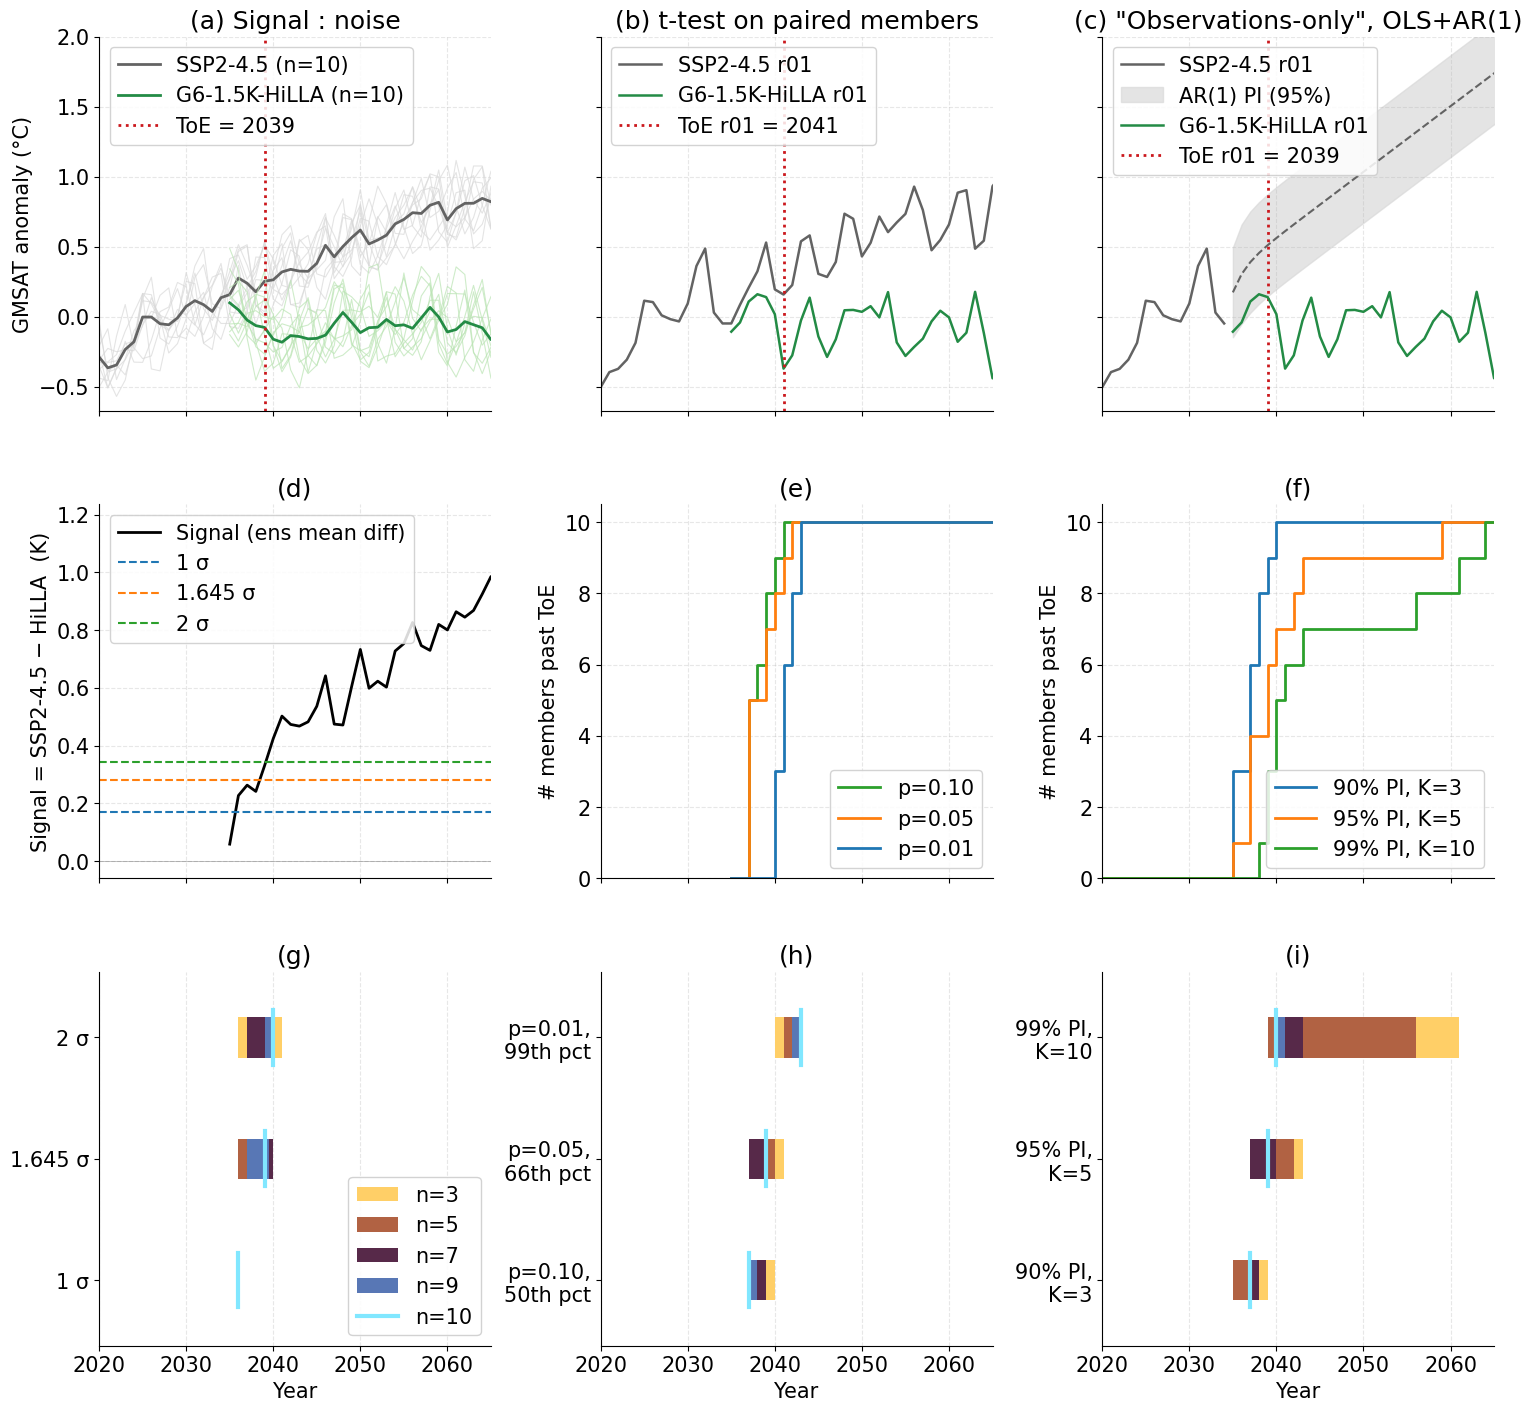

In [10]:

def plot_ens(ax, arr, yrs, color, light_color, label):
    """Plot ensemble members (light) and ensemble mean (bold)."""
    for i, row in enumerate(arr):
        ax.plot(yrs, row, color=light_color, lw=0.8, alpha=0.7, label='_')
    ax.plot(yrs, arr.mean(axis=0), color=color, lw=2.0, label=label)


matplotlib.rcParams['font.size'] = 15

HILLA_COL   = '#238B45'
HILLA_LIGHT = '#BAE4B3'
GRAY        = '#636363'
GRAY_LIGHT  = '#D9D9D9'
RED         = '#CB181D'

PARAM_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c']   # blue, orange, green

# ── Sensitivity colours ───────────────────────────────────────────────────────
GROUP_CENTERS = [0.0, 1.2, 2.4]
BAR_HEIGHT    = 0.40
_N_SENS       = [3, 5, 7, 9, 10]
SENS_COLORS   = {n: plt.cm.managua(i / (len(_N_SENS) - 1)) for i, n in enumerate(_N_SENS)}

def add_sensitivity_panel(ax, boot_data, exact_data, param_labels):
    for n in [3, 5, 7, 9]:
        for pi in range(3):
            vals = [v for v in boot_data[pi][n] if v is not None]
            if len(vals) < 3:
                continue
            p5, p95 = np.percentile(vals, 5), np.percentile(vals, 95)
            ax.barh(GROUP_CENTERS[pi], width=p95 - p5, left=p5,
                    height=BAR_HEIGHT, color=SENS_COLORS[n],
                    edgecolor='none', alpha=1.0,
                    label=f'n={n}' if pi == 0 else '_', zorder=n)
    for pi in range(3):
        if exact_data[pi] is not None:
            y_lo = GROUP_CENTERS[pi] - BAR_HEIGHT / 2 - 0.07
            y_hi = GROUP_CENTERS[pi] + BAR_HEIGHT / 2 + 0.07
            ax.plot([exact_data[pi]] * 2, [y_lo, y_hi],
                    color=SENS_COLORS[10], lw=3.0, zorder=20,
                    label='n=10' if pi == 0 else '_')
    ax.set_yticks(GROUP_CENTERS)
    ax.set_yticklabels(param_labels, fontsize='medium')
    ax.set_ylim(GROUP_CENTERS[0] - 0.65, GROUP_CENTERS[-1] + 0.65)
    ax.grid(ls='--', alpha=0.3, axis='x')
    for sp in ('top', 'right'): ax.spines[sp].set_visible(False)


# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 17), sharex=True)
fig.subplots_adjust(hspace=0.25, wspace=0.28)

axes[0, 1].sharey(axes[0, 0])
axes[0, 2].sharey(axes[0, 0])

# ══════════════════════════════════════════════════════════════════════════════
# ROW 1
# ══════════════════════════════════════════════════════════════════════════════

ax = axes[0, 0]
plot_ens(ax, ssp_arr, ssp_yrs, GRAY, GRAY_LIGHT, 'SSP2-4.5 (n=10)')
plot_ens(ax, hilla_arr, hilla_yrs, HILLA_COL, HILLA_LIGHT, 'G6-1.5K-HiLLA (n=10)')
if sn_toe:
    ax.axvline(sn_toe, color=RED, lw=2.0, ls=':', label=f'ToE = {sn_toe}')
ax.set_title('(a) Signal : noise', fontsize='large', pad=6)
ax.set_ylabel('GMSAT anomaly (°C)', fontsize='medium')
ax.set_ylim(None, 2)
ax.legend(fontsize='medium', loc='upper left', framealpha=0.85)
ax.grid(ls='--', alpha=0.3)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

ax = axes[0, 1]
ax.plot(miroc_ssp245_anom[0].time.values, miroc_ssp245_anom[0].values,
        color=GRAY, lw=1.8, label='SSP2-4.5 r01')
ax.plot(miroc_HiLLA_anom[0].time.values, miroc_HiLLA_anom[0].values,
        color=HILLA_COL, lw=1.8, label='G6-1.5K-HiLLA r01')
if cm_mem_toes[0]:
    ax.axvline(cm_mem_toes[0], color=RED, lw=2.0, ls=':', label=f'ToE r01 = {cm_mem_toes[0]}')
ax.set_title('(b) t-test on paired members', fontsize='large', pad=6)
ax.tick_params(labelleft=False)
ax.legend(fontsize='medium', loc='upper left', framealpha=0.85)
ax.grid(ls='--', alpha=0.3)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

ax = axes[0, 2]
ts_s0 = miroc_ssp245_anom[0]
mask_pre = ts_s0.time.values <= SAI_START - 1
ax.plot(ts_s0.time.values[mask_pre], ts_s0.values[mask_pre],
        color=GRAY, lw=1.8, label='SSP2-4.5 r01')
mu0, lo0, hi0 = ar1_results_all[0]
ax.fill_between(PRED_YEARS, lo0, hi0, color=GRAY_LIGHT, alpha=0.7,
                label='AR(1) PI (95%)', zorder=1)
ax.plot(PRED_YEARS, mu0, color=GRAY, lw=1.5, ls='--', zorder=2)
ts_h0 = miroc_HiLLA_anom[0]
ax.plot(ts_h0.time.values, ts_h0.values, color=HILLA_COL, lw=1.8,
        label='G6-1.5K-HiLLA r01', zorder=3)
if obs_toes_all[0] is not None:
    ax.axvline(obs_toes_all[0], color=RED, lw=2.0, ls=':',
               label=f'ToE r01 = {obs_toes_all[0]}')
ax.set_title('(c) "Observations-only", OLS+AR(1)', fontsize='large', pad=6)
ax.tick_params(labelleft=False)
ax.legend(fontsize='medium', loc='upper left', framealpha=0.85)
ax.grid(ls='--', alpha=0.3)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

# ══════════════════════════════════════════════════════════════════════════════
# ROW 2
# ══════════════════════════════════════════════════════════════════════════════

ax = axes[1, 0]
ax.plot(sn_years, sn_signal, color='black', lw=2.0, label='Signal (ens mean diff)')
ax.axhline(0, color='k', lw=0.7, alpha=0.25)
for pi, p in enumerate(M1_PARAMS):
    ax.axhline(p['k'] * sn_sigma, color=PARAM_COLORS[pi], lw=1.5, ls='--', label=p['label'])
ax.set_title('(d)', fontsize='large', pad=6)
ax.set_ylabel('Signal = SSP2-4.5 − HiLLA  (K)', fontsize='medium')
ax.legend(fontsize='medium', loc='upper left', framealpha=0.85)
ax.grid(ls='--', alpha=0.3)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

ax = axes[1, 1]
yrs_pv = sorted(cm_pvals_all[0].keys())
for pi, p in reversed(list(enumerate(M2_PARAMS))):
    member_toes = cm_all_member_toes[p['alpha']]
    cum = np.array([sum(1 for t in member_toes if t is not None and t <= y)
                    for y in yrs_pv])
    ax.step(yrs_pv, cum, color=PARAM_COLORS[pi], lw=2.0, where='post',
            label=f"p={p['alpha']:.2f}")
ax.set_title('(e)', fontsize='large', pad=6)
ax.set_ylabel('# members past ToE', fontsize='medium')
ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
ax.set_ylim(0, N_MEM + 0.5)
ax.legend(fontsize='medium', loc='lower right', framealpha=0.85)
ax.grid(ls='--', alpha=0.3)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

ax = axes[1, 2]
all_yrs_f = np.arange(PLOT_START, PLOT_END + 1)
for pi, p in enumerate(M3_PARAMS):
    member_toes = obs_all_member_toes[(p['ci'], p['K'])]
    cum = np.array([sum(1 for t in member_toes if t is not None and t <= y)
                    for y in all_yrs_f])
    ax.step(all_yrs_f, cum, color=PARAM_COLORS[pi], lw=2.0, where='post', label=p['label'])
ax.set_title('(f)', fontsize='large', pad=6)
ax.set_ylabel('# members past ToE', fontsize='medium')
ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
ax.set_ylim(0, N_MEM + 0.5)
ax.legend(fontsize='medium', loc='lower right', framealpha=0.85)
ax.grid(ls='--', alpha=0.3)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

# ══════════════════════════════════════════════════════════════════════════════
# ROW 3
# ══════════════════════════════════════════════════════════════════════════════

axes[2, 0].set_title('(g)', fontsize='large', pad=6)
axes[2, 1].set_title('(h)', fontsize='large', pad=6)
axes[2, 2].set_title('(i)', fontsize='large', pad=6)

m2_labels = [p['label'].replace(', ', ',\n') for p in M2_PARAMS]
m3_labels = [p['label'].replace(', ', ',\n') for p in M3_PARAMS]

add_sensitivity_panel(axes[2, 0], sn_boot,  sn_exact,  [p['label'] for p in M1_PARAMS])
add_sensitivity_panel(axes[2, 1],
                      {pi: cm_boot[2 - pi] for pi in range(3)},
                      cm_exact[::-1],
                      m2_labels[::-1])
add_sensitivity_panel(axes[2, 2], obs_boot, obs_exact, m3_labels)

axes[0, 0].set_xlim(PLOT_START, 2065)
for ax in axes[2]:
    ax.set_xlabel('Year', fontsize='medium')

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
leg_elements = [
    Patch(facecolor=SENS_COLORS[n], edgecolor='none', label=f'n={n}')
    for n in [3, 5, 7, 9]
] + [Line2D([0], [0], color=SENS_COLORS[10], lw=3.0, label='n=10')]
axes[2, 0].legend(handles=leg_elements, fontsize='medium', loc='lower right', framealpha=0.88)

plt.savefig('Figures/ToE_methods_comparison_v2.png', dpi=200, bbox_inches='tight')
plt.show()
